In [1]:
import pandas as pd

df = pd.read_csv("Global_Pollution_Analysis (2).csv")

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    str    
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float64
 11  Popu

In [3]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (200, 13)


In [4]:
df.isnull().sum()

Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64

In [5]:
df.describe()

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
count,200.000000,200.00000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,2009.335000,180.62695,115.068100,76.488550,52891.68150,260.448700,24.878100,27.799700,24492.893550,9.43575,104.271300,35307.602400
std,5.765325,67.07331,47.580911,39.692727,27224.49169,147.141923,14.470892,12.361879,14421.356002,5.57567,56.906574,19481.714455
min,2000.000000,50.30000,31.130000,11.150000,1019.37000,11.730000,1.920000,5.040000,542.950000,0.53000,2.320000,1298.700000
25%,2004.000000,134.97250,74.550000,40.895000,31201.97250,118.355000,11.220000,17.700000,12843.882500,4.58250,60.960000,19525.020000
50%,2010.000000,183.38500,112.305000,78.600000,55299.15000,273.140000,25.355000,29.170000,24121.540000,9.22500,104.965000,35043.325000
75%,2014.000000,237.42500,157.477500,109.212500,74805.82500,384.957500,38.550000,37.072500,36516.232500,13.99750,150.930000,51629.547500
max,2019.000000,297.95000,199.320000,149.230000,99739.36000,499.980000,49.690000,49.560000,49852.280000,19.98000,198.820000,69143.140000


In [6]:
print(df.columns.tolist())

['Country', 'Year', 'Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'Industrial_Waste (in tons)', 'Energy_Recovered (in GWh)', 'CO2_Emissions (in MT)', 'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)', 'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)', 'GDP_Per_Capita (in USD)']


In [7]:
pollution_columns = [
    'Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index'
]

df['Pollution_Score'] = df[pollution_columns].mean(axis=1)

df[['Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index',
    'Pollution_Score']].head()

,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Pollution_Score
0,272.70,124.27,51.95,149.640000
1,86.72,60.34,117.22,88.093333
2,91.59,83.36,121.72,98.890000
3,280.61,67.16,93.58,147.116667
4,179.16,127.53,121.55,142.746667


In [8]:
def classify_pollution(score):
    if score < 40:
        return 'Low'
    elif score < 70:
        return 'Medium'
    else:
        return 'High'

df['Pollution_Severity'] = df['Pollution_Score'].apply(classify_pollution)

In [9]:
def classify_pollution(score):
    if score < 40:
        return 'Low'
    elif score < 70:
        return 'Medium'
    else:
        return 'High'

df['Pollution_Severity'] = df['Pollution_Score'].apply(classify_pollution)

In [10]:
df[['Pollution_Score', 'Pollution_Severity']].head(10)

,Pollution_Score,Pollution_Severity
0,149.640000,High
1,88.093333,High
2,98.890000,High
3,147.116667,High
4,142.746667,High
5,99.726667,High
6,161.853333,High
7,177.016667,High
8,134.383333,High
9,144.096667,High


In [11]:
df['Pollution_Severity'].value_counts()

Pollution_Severity
High      189
Medium     11
Name: count, dtype: int64

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

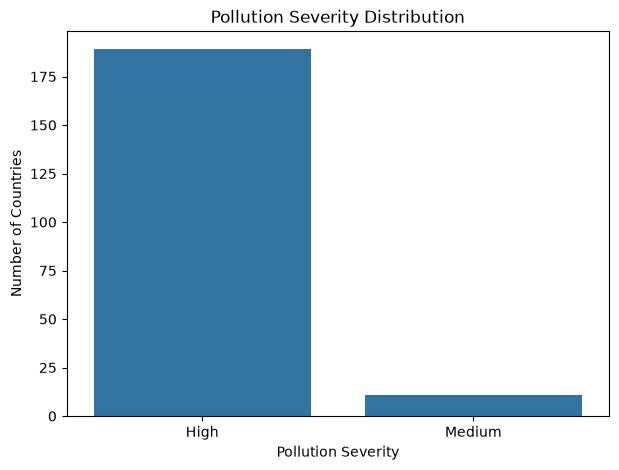

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Pollution_Severity')

plt.title('Pollution Severity Distribution')
plt.xlabel('Pollution Severity')
plt.ylabel('Number of Countries')
plt.show()

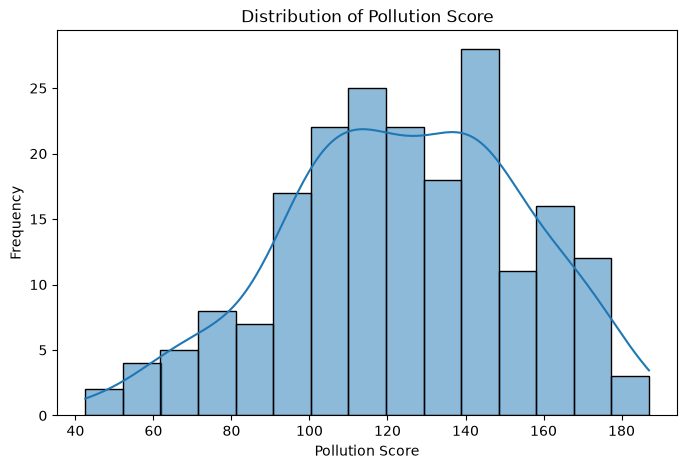

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Pollution_Score'], bins=15, kde=True)

plt.title('Distribution of Pollution Score')
plt.xlabel('Pollution Score')
plt.ylabel('Frequency')
plt.show()

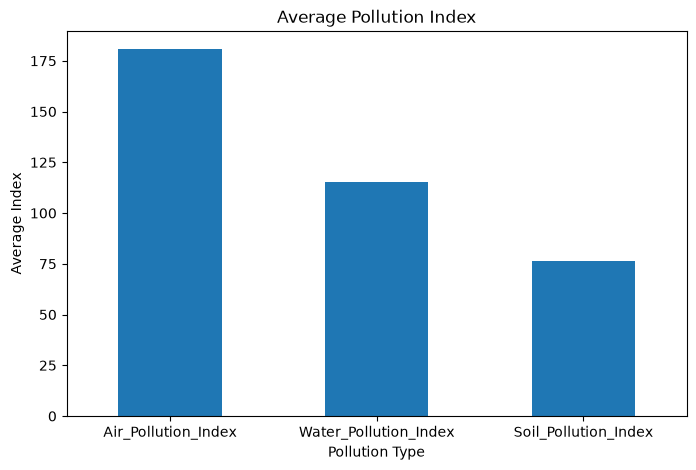

In [15]:
pollution_columns = [
    'Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index'
]

df[pollution_columns].mean().plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Average Pollution Index')
plt.xlabel('Pollution Type')
plt.ylabel('Average Index')
plt.xticks(rotation=0)
plt.show()

In [16]:
features = [
    'Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index',
    'Industrial_Waste (in tons)',
    'Energy_Recovered (in GWh)',
    'CO2_Emissions (in MT)',
    'Renewable_Energy (%)',
    'Plastic_Waste_Produced (in tons)',
    'Energy_Consumption_Per_Capita (in MWh)',
    'Population (in millions)',
    'GDP_Per_Capita (in USD)'
]

X = df[features]
y = df['Pollution_Severity']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (200, 11)
Target shape: (200,)


In [17]:
print(y.value_counts())

Pollution_Severity
High      189
Medium     11
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 11)
Testing data: (40, 11)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")

Scaling completed successfully.


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")

Scaling completed successfully.


In [22]:
from sklearn.naive_bayes import MultinomialNB

In [23]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


In [24]:
from sklearn.metrics import accuracy_score

In [25]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.55


In [26]:
from sklearn.metrics import confusion_matrix, classification_report

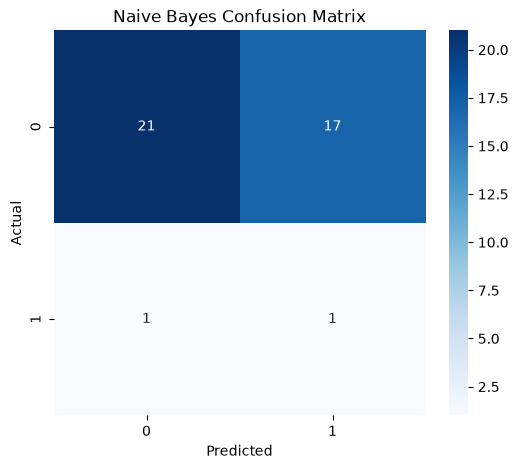

In [27]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [28]:
print("Naive Bayes Classification Report:\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Classification Report:

              precision    recall  f1-score   support

        High       0.95      0.55      0.70        38
      Medium       0.06      0.50      0.10         2

    accuracy                           0.55        40
   macro avg       0.51      0.53      0.40        40
weighted avg       0.91      0.55      0.67        40



In [29]:
from sklearn.neighbors import KNeighborsClassifier

In [30]:
k_values = range(1, 16)
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    
    knn_accuracies.append(accuracy)

print("K values:", list(k_values))
print("Accuracies:", knn_accuracies)

K values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Accuracies: [0.975, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95]


In [31]:
import numpy as np

In [32]:
best_k = list(k_values)[np.argmax(knn_accuracies)]
best_accuracy = max(knn_accuracies)

print("Best K:", best_k)
print("Best KNN Accuracy:", best_accuracy)

Best K: 1
Best KNN Accuracy: 0.975


In [33]:
best_knn = KNeighborsClassifier(n_neighbors=best_k)

best_knn.fit(X_train_scaled, y_train)

y_pred_knn = best_knn.predict(X_test_scaled)

print("Best KNN model trained successfully.")

Best KNN model trained successfully.


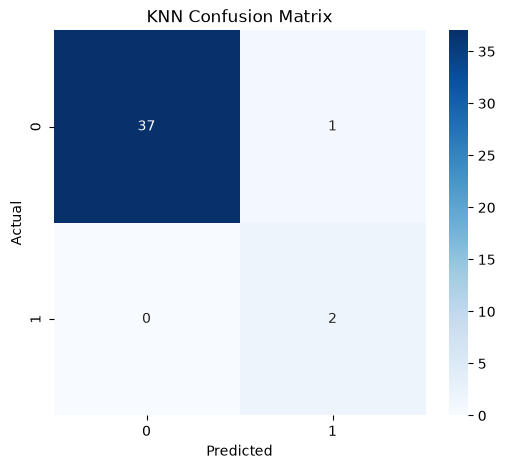

In [34]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [35]:
print("KNN Classification Report:\n")
print(classification_report(y_test, y_pred_knn))

KNN Classification Report:

              precision    recall  f1-score   support

        High       1.00      0.97      0.99        38
      Medium       0.67      1.00      0.80         2

    accuracy                           0.97        40
   macro avg       0.83      0.99      0.89        40
weighted avg       0.98      0.97      0.98        40



In [36]:
from sklearn.tree import DecisionTreeClassifier

In [37]:
from sklearn.model_selection import GridSearchCV

In [38]:
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10]
}

dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'max_depth': 3, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.9375


In [39]:
best_dt = grid_search.best_estimator_

y_pred_dt = best_dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.975


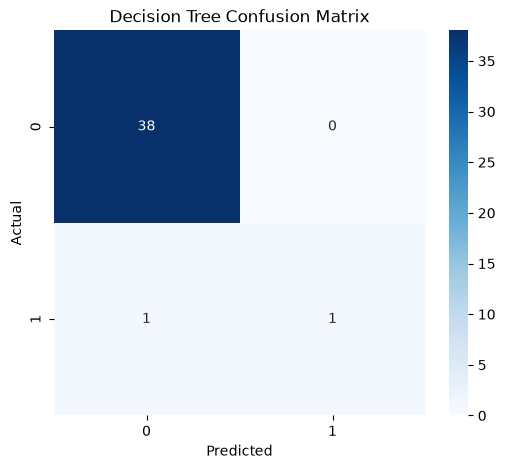

In [40]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [41]:
print("Decision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classification Report:

              precision    recall  f1-score   support

        High       0.97      1.00      0.99        38
      Medium       1.00      0.50      0.67         2

    accuracy                           0.97        40
   macro avg       0.99      0.75      0.83        40
weighted avg       0.98      0.97      0.97        40



In [42]:
print("Best Decision Tree Parameters:")
print(grid_search.best_params_)

Best Decision Tree Parameters:
{'max_depth': 3, 'min_samples_split': 2}


In [43]:
model_comparison = pd.DataFrame({
    'Model': [
        'Multinomial Naive Bayes',
        'K-Nearest Neighbors',
        'Decision Tree'
    ],
    'Accuracy': [
        nb_accuracy,
        best_accuracy,
        dt_accuracy
    ]
})

model_comparison

,Model,Accuracy
0,Multinomial Naive Bayes,0.550
1,K-Nearest Neighbors,0.975
2,Decision Tree,0.975


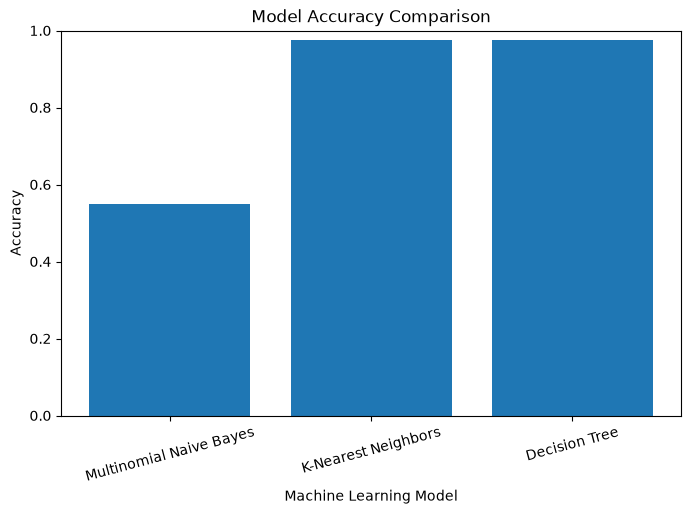

In [44]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison['Model'],
    model_comparison['Accuracy']
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Machine Learning Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.show()

In [45]:
model_comparison['Accuracy (%)'] = (
    model_comparison['Accuracy'] * 100
).round(2)

model_comparison

,Model,Accuracy,Accuracy (%)
0,Multinomial Naive Bayes,0.550,55.0
1,K-Nearest Neighbors,0.975,97.5
2,Decision Tree,0.975,97.5


In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [47]:
models = {
    'Multinomial Naive Bayes': y_pred_nb,
    'K-Nearest Neighbors': y_pred_knn,
    'Decision Tree': y_pred_dt
}

results = []

for model_name, predictions in models.items():
    results.append({
        'Model': model_name,
        'Precision': precision_score(
            y_test, predictions, average='weighted', zero_division=0
        ),
        'Recall': recall_score(
            y_test, predictions, average='weighted', zero_division=0
        ),
        'F1-Score': f1_score(
            y_test, predictions, average='weighted', zero_division=0
        )
    })

metrics_comparison = pd.DataFrame(results)

metrics_comparison

,Model,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.909596,0.550,0.670000
1,K-Nearest Neighbors,0.983333,0.975,0.977333
2,Decision Tree,0.975641,0.975,0.970996


In [48]:
metrics_percentage = metrics_comparison.copy()

metric_columns = ['Precision', 'Recall', 'F1-Score']

metrics_percentage[metric_columns] = (
    metrics_percentage[metric_columns] * 100
).round(2)

metrics_percentage

,Model,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,90.96,55.0,67.00
1,K-Nearest Neighbors,98.33,97.5,97.73
2,Decision Tree,97.56,97.5,97.10


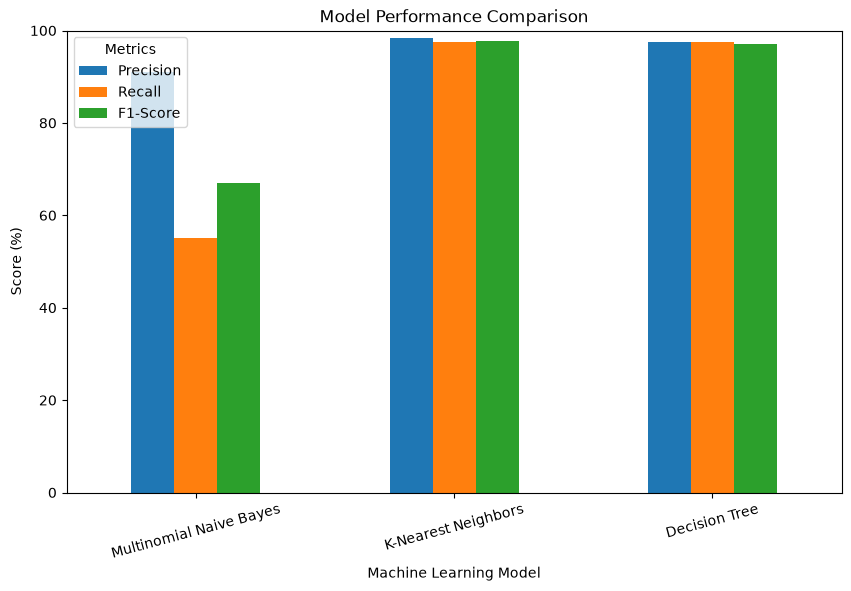

In [49]:
metrics_percentage.set_index('Model')[metric_columns].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Model Performance Comparison')
plt.xlabel('Machine Learning Model')
plt.ylabel('Score (%)')
plt.xticks(rotation=15)
plt.ylim(0, 100)
plt.legend(title='Metrics')
plt.show()

In [50]:
final_results = model_comparison.merge(
    metrics_percentage,
    on='Model'
)

final_results

,Model,Accuracy,Accuracy (%),Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.550,55.0,90.96,55.0,67.00
1,K-Nearest Neighbors,0.975,97.5,98.33,97.5,97.73
2,Decision Tree,0.975,97.5,97.56,97.5,97.10


In [51]:
final_results.to_csv(
    'model_comparison_results.csv',
    index=False
)

print("Final results saved successfully.")

Final results saved successfully.


In [52]:
severity_summary = df['Pollution_Severity'].value_counts()

print("Pollution Severity Summary:")
print(severity_summary)

Pollution Severity Summary:
Pollution_Severity
High      189
Medium     11
Name: count, dtype: int64


In [53]:
print("Average Energy Recovered:",
      df['Energy_Recovered (in GWh)'].mean())

print("Maximum Energy Recovered:",
      df['Energy_Recovered (in GWh)'].max())

print("Minimum Energy Recovered:",
      df['Energy_Recovered (in GWh)'].min())

Average Energy Recovered: 260.44870000000003
Maximum Energy Recovered: 499.98
Minimum Energy Recovered: 11.73


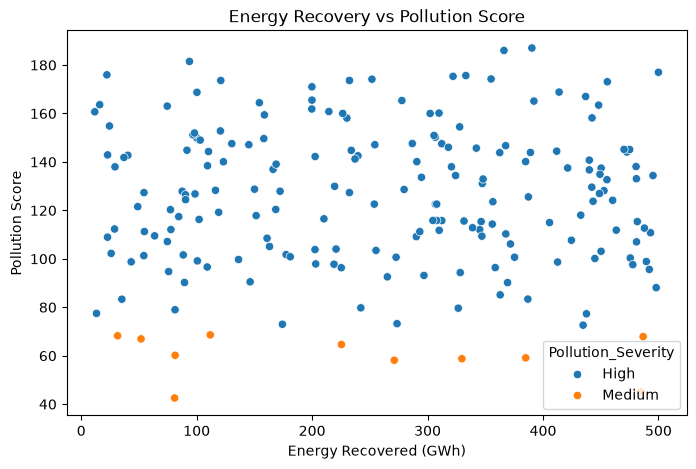

In [54]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Energy_Recovered (in GWh)',
    y='Pollution_Score',
    hue='Pollution_Severity'
)

plt.title('Energy Recovery vs Pollution Score')
plt.xlabel('Energy Recovered (GWh)')
plt.ylabel('Pollution Score')
plt.show()

In [55]:
print(final_results)
print("\nBest K:", best_k)
print("\nBest Decision Tree Parameters:", grid_search.best_params_)
print("\nPollution Severity Summary:")
print(severity_summary)

                     Model  Accuracy  Accuracy (%)  Precision  Recall  \
0  Multinomial Naive Bayes     0.550          55.0      90.96    55.0   
1      K-Nearest Neighbors     0.975          97.5      98.33    97.5   
2            Decision Tree     0.975          97.5      97.56    97.5   

   F1-Score  
0     67.00  
1     97.73  
2     97.10  

Best K: 1

Best Decision Tree Parameters: {'max_depth': 3, 'min_samples_split': 2}

Pollution Severity Summary:
Pollution_Severity
High      189
Medium     11
Name: count, dtype: int64
